In [1]:
import os
import sys
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# Ensure we can import from the project root
sys.path.append(str(Path.cwd().parent))

from src.data_processor import load_and_preprocess_photos
from src.viz import (
    plot_country_timestamp_report,
    plot_city_timestamp_report,
    generate_full_country_report,
    generate_country_markdown_report
)
from src.cache import ThumbnailCache
from src.config import CACHE_PATH

In [3]:
df, travel, home = load_and_preprocess_photos()

print(f"Total photos : {len(df)}")
print(f"Travel photos: {len(travel)} across {travel['country'].nunique()} countries")

Total photos : 7125
Travel photos: 4752 across 12 countries


In [4]:
cache = ThumbnailCache(CACHE_PATH)

[cache] Loaded 3968 entries from C:\Users\Aya\Desktop\Immich\data\thumbnails_analysis.json


In [5]:
# See top countries to pick from
travel["country"].value_counts().head(10)

country
Japan                          839
Indonesia                      704
Sri Lanka                      629
Vietnam                        627
People's Republic of China     500
United Republic of Tanzania    438
Cambodia                       388
Malaysia                       281
United Arab Emirates           243
Saudi Arabia                    63
Name: count, dtype: int64

Plotting timeline for: ['Sri Lanka', 'Malaysia', 'Cambodia', 'Vietnam', 'Indonesia']


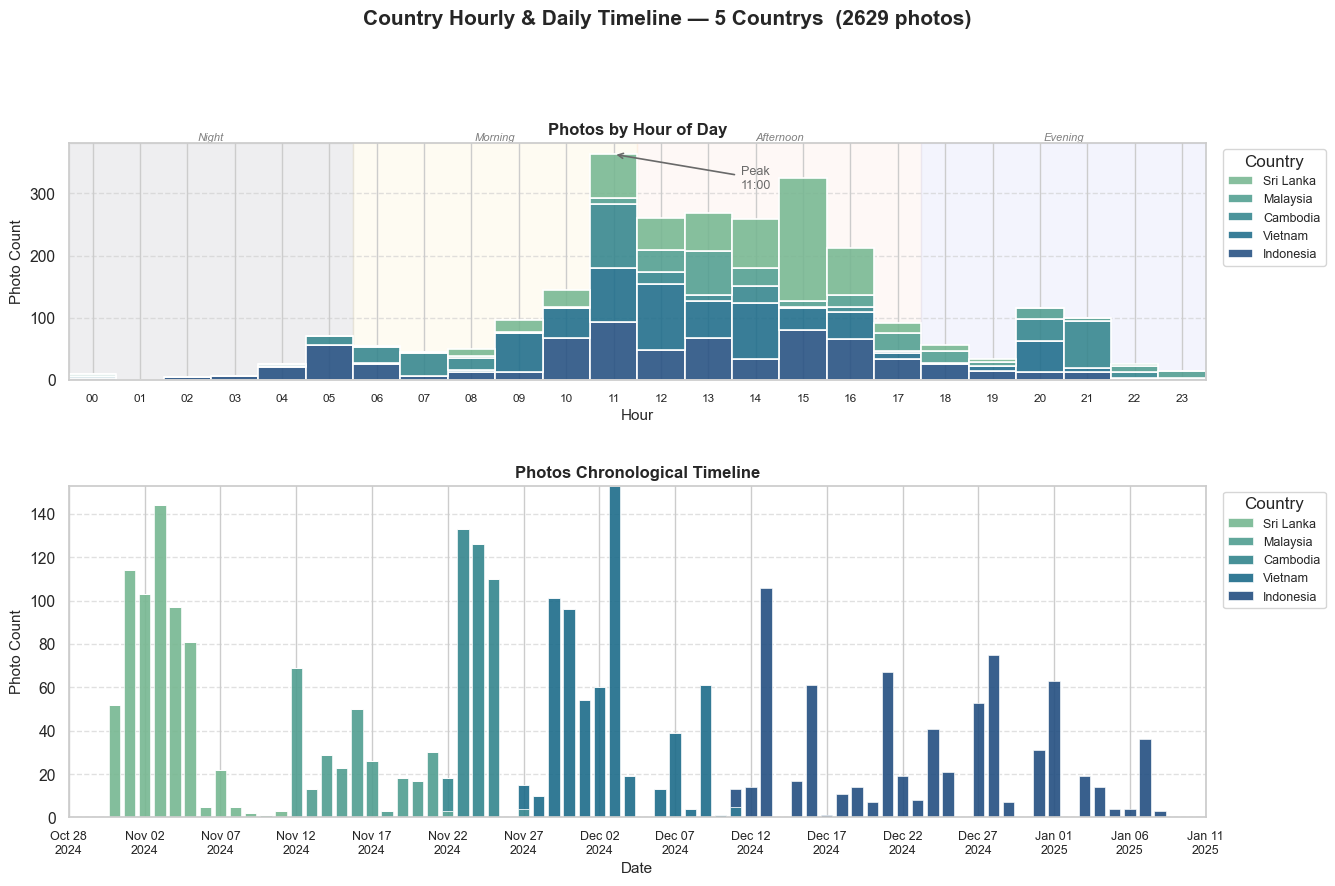

In [6]:
# Test multiple countries together!

target_countries = ["Sri Lanka","Malaysia","Cambodia","Vietnam","Indonesia"]

print(f"Plotting timeline for: {target_countries}")
plot_country_timestamp_report(travel, target_countries)

Plotting timeline for: ['Egypt']


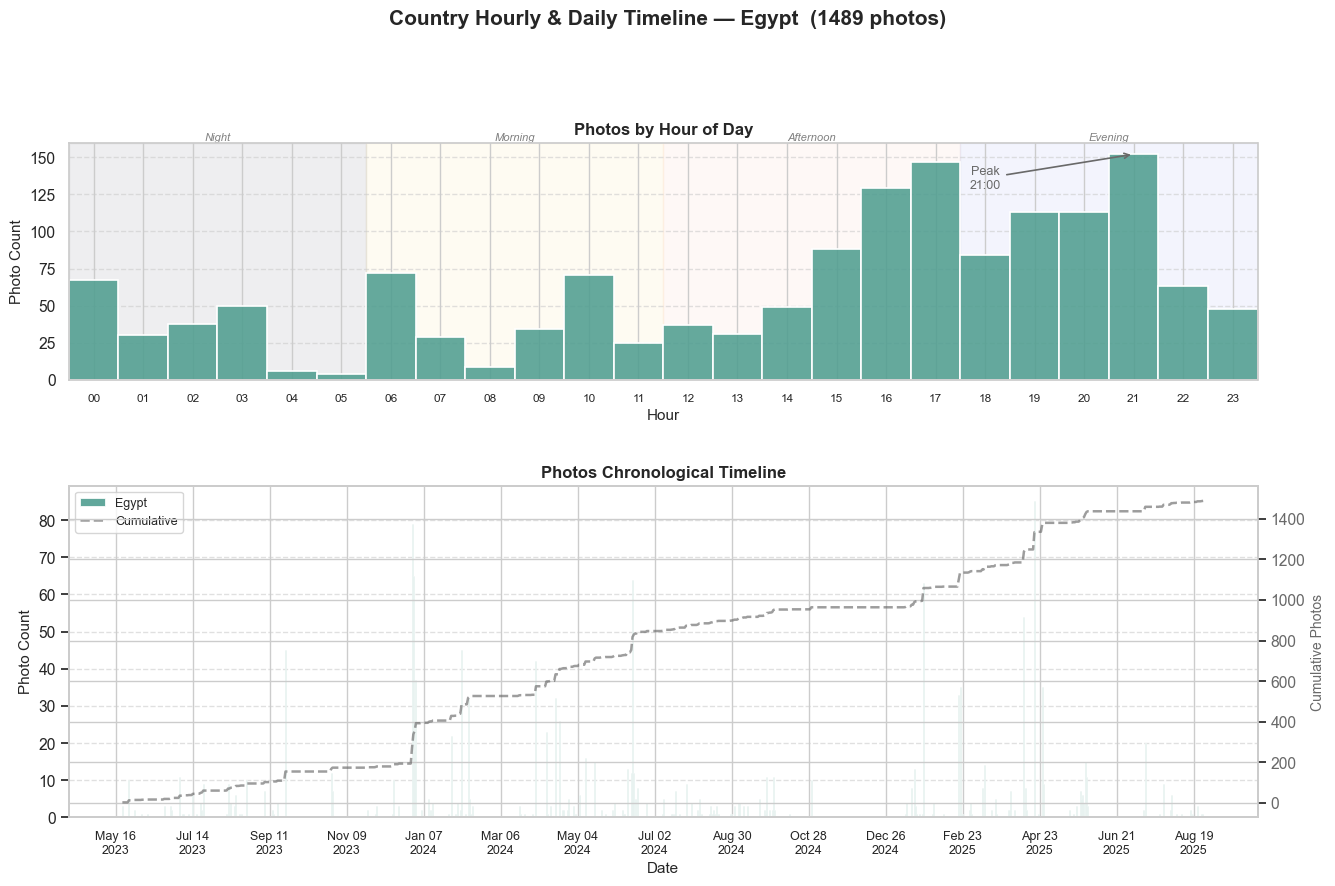

In [7]:
target_countries = ["Egypt"]

print(f"Plotting timeline for: {target_countries}")
plot_country_timestamp_report(home, target_countries)

You can also compare cities side-by-side using `plot_city_timestamp_report`:

In [ ]:
target_cities = ["Kyoto", "Tokyo", "Osaka"]

print(f"Plotting timeline for: {target_cities}")
plot_city_timestamp_report(travel, target_cities)

# Full Report for A country

In [8]:
generate_full_country_report(
    travel=travel,
    results=cache,
    country="Japan",             # Change to whichever country you want
    base_save_dir="reports"      # It will create 'reports/Japan/'
)

Generating full report for Japan in 'reports\Japan'...
  -> Generating reports for city: Tomisato
  -> Generating reports for city: Minato City
  -> Generating reports for city: Azabu-jūban
  -> Generating reports for city: Higashi-nihombashi
  -> Generating reports for city: Machiya
  -> Generating reports for city: Nihonbashi-bakurochō
  -> Generating reports for city: Kanda-awajichō
  -> Generating reports for city: Heiwadai
  -> Generating reports for city: Tokyo
  -> Generating reports for city: Hatsudai
  -> Generating reports for city: Sakuragaokachō
  -> Generating reports for city: Daikan’yamachō
  -> Generating reports for city: Hatchōbori
  -> Generating reports for city: Hashima
  -> Generating reports for city: Mukō
  -> Generating reports for city: Kyoto
  -> Generating reports for city: Kamigyō-ku
  -> Generating reports for city: Arashiyama
  -> Generating reports for city: Nara-shi
  -> Generating reports for city: Osaka
  -> Generating reports for city: Sakai
  -> Gen

In [ ]:
generate_country_markdown_report(travel=travel, results=cache)

TypeError: generate_country_markdown_report() missing 1 required positional argument: 'country'